In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [4]:
df = pd.read_csv("/content/sample_data/heart_disease.csv")

df.head()

,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,Male,39,postgraduate,0,0.0,0.0,no,0,0,195.0,106.0,70.0,26.97,80.0,77.0,No
1,Female,46,primaryschool,0,0.0,0.0,no,0,0,250.0,121.0,81.0,28.73,95.0,76.0,No
2,Male,48,uneducated,1,20.0,0.0,no,0,0,245.0,127.5,80.0,25.34,75.0,70.0,No
3,Female,61,graduate,1,30.0,0.0,no,1,0,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,Female,46,graduate,1,23.0,0.0,no,0,0,285.0,130.0,84.0,23.10,85.0,85.0,No


In [5]:
print(df.shape)

df.info()

df.describe()

(4238, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   object 
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   object 
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  Heart_ stroke    4238 non-null   object 
dtypes: float64(8), int64(4), object(4)
memory usage: 

,age,currentSmoker,cigsPerDay,BPMeds,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,4238.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000
mean,49.584946,0.494101,9.003089,0.029630,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753
std,8.572160,0.500024,11.920094,0.169584,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998
min,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000
25%,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000
50%,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000
75%,56.000000,1.000000,20.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000
max,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000


In [6]:
df.isnull().sum()

,0
Gender,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [7]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.shape)

Duplicates: 0
After removing duplicates: (4238, 16)


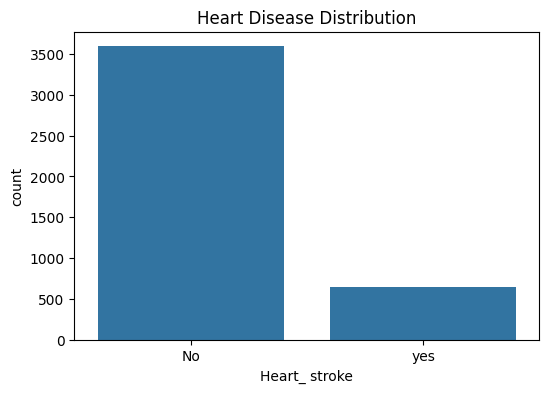

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Heart_ stroke',
    data=df
)

plt.title("Heart Disease Distribution")
plt.show()

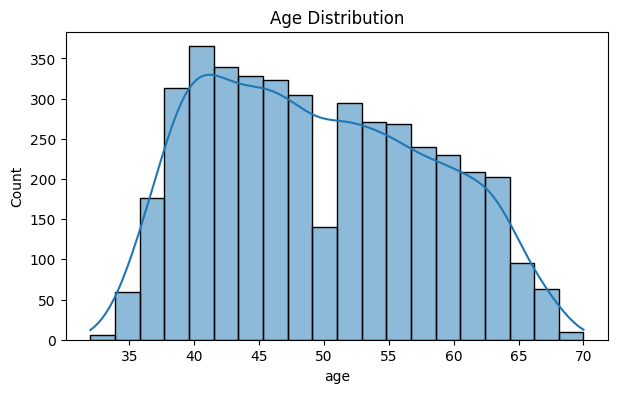

In [9]:
plt.figure(figsize=(7,4))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

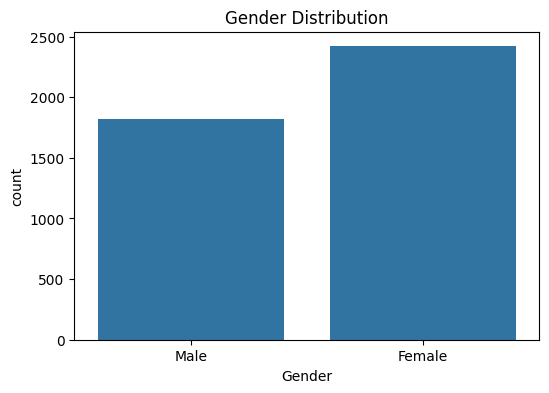

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")

plt.show()

In [11]:
df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0
})

In [12]:
encoder = LabelEncoder()


df['education'] = encoder.fit_transform(
    df['education']
)


df['prevalentStroke'] = encoder.fit_transform(
    df['prevalentStroke']
)


df['Heart_ stroke'] = encoder.fit_transform(
    df['Heart_ stroke']
)

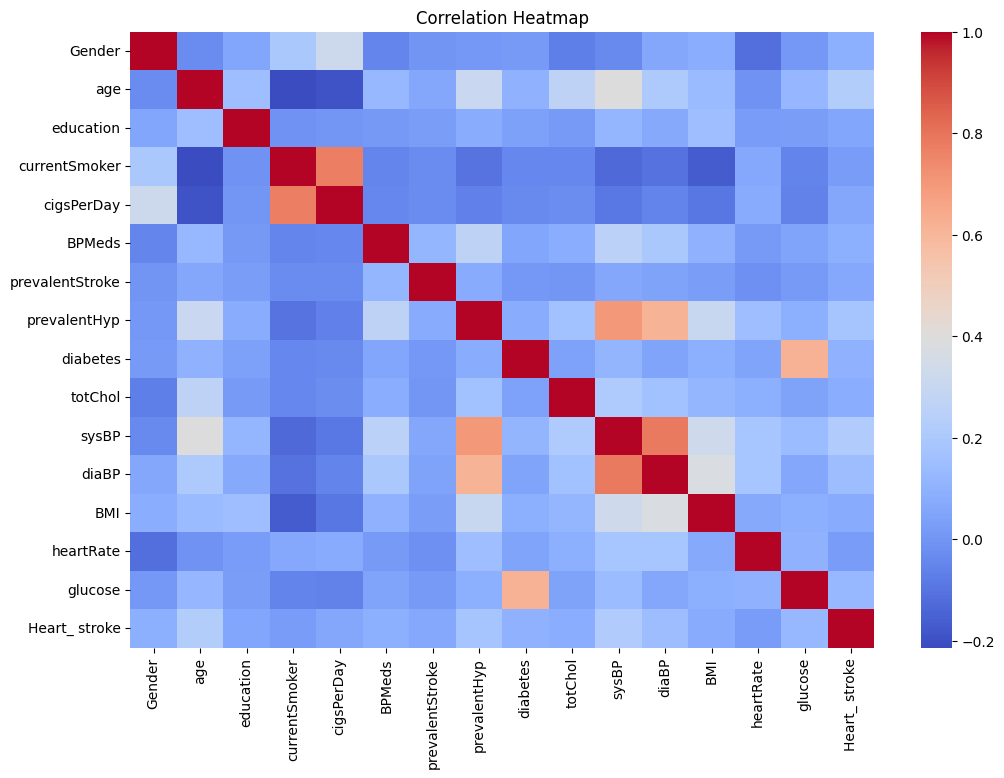

In [13]:
plt.figure(figsize=(12,8))


sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)


plt.title("Correlation Heatmap")

plt.show()

In [14]:
X = df.drop(
    'Heart_ stroke',
    axis=1
)


y = df['Heart_ stroke']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
imputer = SimpleImputer(strategy='median')


X_train = imputer.fit_transform(X_train)


X_test = imputer.transform(X_test)

In [17]:
scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)

In [18]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)


knn = KNeighborsClassifier(
    n_neighbors=5
)


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [19]:
lr.fit(
    X_train,
    y_train
)


knn.fit(
    X_train,
    y_train
)


rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [20]:
lr_pred = lr.predict(X_test)

knn_pred = knn.predict(X_test)

rf_pred = rf.predict(X_test)

In [21]:
models = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "Random Forest": rf_pred
}



results=[]


for name,pred in models.items():

    results.append({

        "Model":name,

        "Accuracy":
        accuracy_score(y_test,pred),

        "Precision":
        precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "F1 Score":
        f1_score(
            y_test,
            pred,
            zero_division=0
        )

    })


results_df = pd.DataFrame(results)


results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.847877,0.500000,0.069767,0.122449
1,KNN,0.830189,0.222222,0.046512,0.076923
2,Random Forest,0.844340,0.363636,0.031008,0.057143


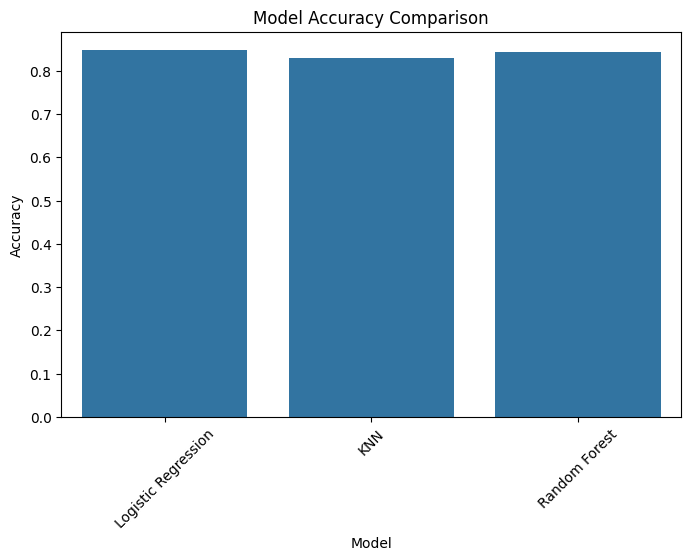

In [22]:
plt.figure(figsize=(8,5))


sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)


plt.xticks(rotation=45)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

In [23]:
for name,pred in models.items():
    print(name)

    print(
        classification_report(
            y_test,
            pred,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       719
           1       0.50      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848

KNN
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       719
           1       0.22      0.05      0.08       129

    accuracy                           0.83       848
   macro avg       0.54      0.51      0.49       848
weighted avg       0.75      0.83      0.78       848

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.36      0.03      0.06       129

    accuracy                           0.84       848
   macro avg       0.61      0.51      0.49       848
weighted avg       0.78      0.84   

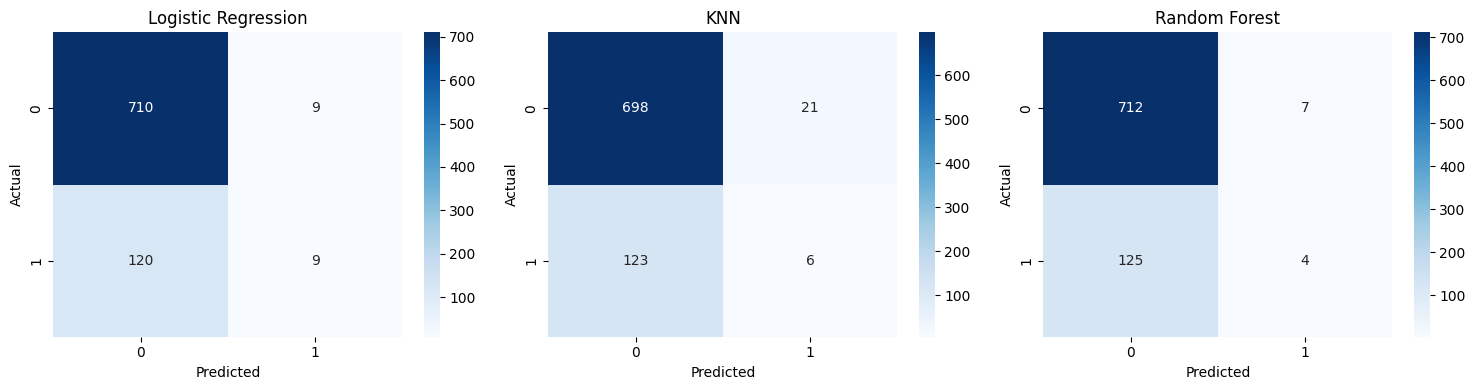

In [24]:
fig,axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)


for ax,(name,pred) in zip(
    axes,
    models.items()
):

    cm = confusion_matrix(
        y_test,
        pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )

    ax.set_title(name)

    ax.set_xlabel(
        "Predicted"
    )

    ax.set_ylabel(
        "Actual"
    )


plt.tight_layout()

plt.show()

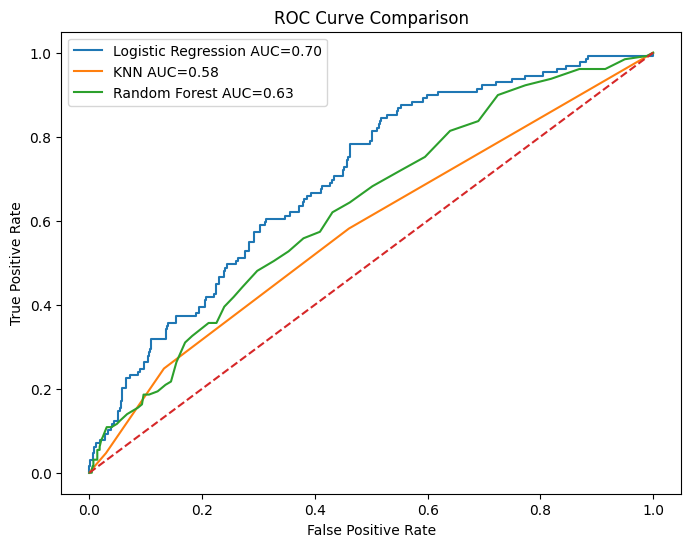

In [25]:
plt.figure(figsize=(8,6))


probabilities = {

"Logistic Regression":
lr.predict_proba(X_test)[:,1],

"KNN":
knn.predict_proba(X_test)[:,1],

"Random Forest":
rf.predict_proba(X_test)[:,1]

}



for name,prob in probabilities.items():

    fpr,tpr,_ = roc_curve(
        y_test,
        prob
    )


    auc = roc_auc_score(
        y_test,
        prob
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.2f}"
    )



plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

In [26]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance":
    rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,sysBP,0.134319
12,BMI,0.125039
1,age,0.124961
9,totChol,0.121522
14,glucose,0.118554
11,diaBP,0.115900
13,heartRate,0.096743
4,cigsPerDay,0.051041
2,education,0.040842
0,Gender,0.020580


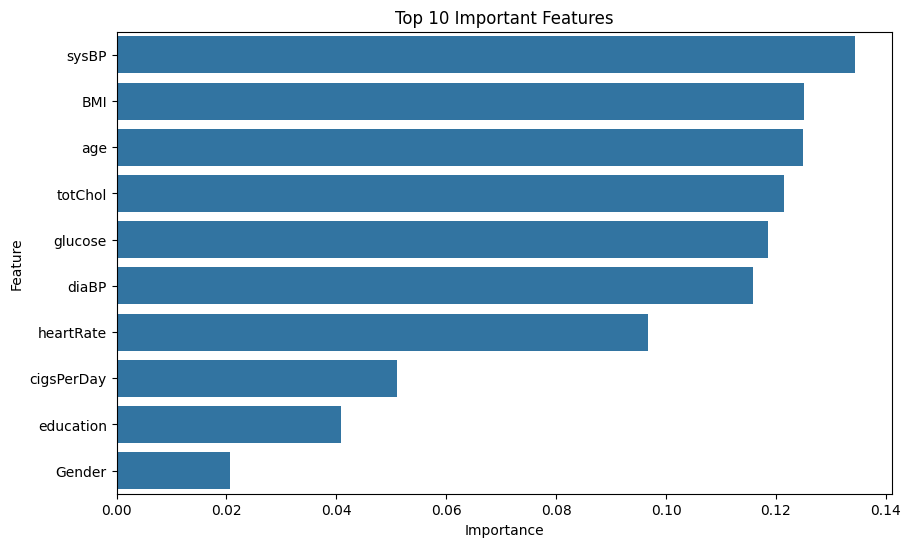

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()